In [1]:
from pathlib import Path
import re
import pandas as pd
import seaborn as sns

In [2]:
WORKLOADS = ["faiss_10M", "lulesh2.0_s400", "DuckDB-TPCH-sf100", "DuckDB-TPCDS-sf100", "mg.D.x", "XSBench", "pr-kron.sg", "pr-twitter.sg", "bc-kron.sg", "bc-twitter.sg"]

In [3]:
def parse_time_value(raw: str) -> float:
    """Convert strings like '7m56.676s' into seconds."""
    
    raw = raw.strip()
    match = re.fullmatch(r"(?:(\d+)m)?([0-9.]+)s", raw)
    if not match:
        raise ValueError(f"Unrecognized time format: {raw}")
    minutes = int(match.group(1) or 0)
    seconds = float(match.group(2))
    return minutes * 60 + seconds

def parse_time_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "\t" not in line:
                continue
            key, value = line.split("\t", 1)
            metrics[key] = parse_time_value(value)
    return metrics

def extract_mib(path: Path) -> int | None:
    match = re.search(r"(\d+)MiB", path.name)
    return int(match.group(1)) if match else None


def extract_run(path: Path) -> int | None:
    match = re.search(r"run(\d+)", path.name)
    return int(match.group(1)) if match else None

def parse_log_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "=" not in line:
                continue
            key, value = line.split("=", 1)
            metrics[key.strip()] = float(value.strip())
    return metrics

In [4]:
def generate_df(roots_gen: callable) -> pd.DataFrame:
    dfs = []

    for workload in WORKLOADS:
        records: list[dict] = []
        for label, (kernel, root) in roots_gen(workload).items():
            for path in sorted(root.glob("*.time")):
                if "train" in path.name:
                    continue
                metrics = parse_time_file(path)
                try:
                    log_metrics = parse_log_file(Path(f"{path.parent}/max_dram_hugepages_{path.stem}.log"))
                except FileNotFoundError:
                    log_metrics = {}
                    
                    
                
                    
                m = re.search(
                    r"_discounted_reward_(\d+)_.*_l2-(true|false)_(\d+)_([0-9]*\.?[0-9]+)\.time$",
                    path.name,
                )
                parsed = {}
                if m:
                    parsed = {
                        "discounted_reward": int(m.group(1)),
                        "minmax": m.group(2) == "true",
                        "hist_length": int(m.group(3)),
                        "penalty": float(m.group(4)),
                    }

                records.append({
                    "policy": label,
                    "kernel": kernel,
                    "file": path.name,
                    "MiB": extract_mib(path),
                    "run": extract_run(path),
                    **metrics,
                    **log_metrics,
                    **parsed,
                })

        df = pd.DataFrame(records)
        df["workload"] = workload

        dfs.append(df)
    df = pd.concat(dfs, ignore_index=True)
    return df

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
    
def plot_df(df: pd.DataFrame):

    policy_order = list(dict.fromkeys(df["policy"]))
    policy_palette = dict(zip(policy_order, sns.color_palette(n_colors=len(policy_order))))

    def minmax_interval(values):
        return values.min(), values.max()

    for workload_group in df.groupby("workload"):
        print(workload_group[0])
        plt.figure(figsize=(14, 8))
        ax = sns.barplot(
            workload_group[1],
            x="MiB",
            y="real",
            hue="policy",
            hue_order=policy_order,
            palette=policy_palette,
            estimator="mean",
            errorbar=minmax_interval,
        )
        ax.set(title=workload_group[0], xlabel="Memory Footprint (MiB)", ylabel="Execution Time (s)")

        for container in ax.containers:
            labels = [f"{value:.2f}" if pd.notna(value) else "" for value in container.datavalues]
            ax.bar_label(container, labels=labels, padding=3, fontsize=9)

        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax * 1.08)

        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
        plt.tight_layout()
        plt.show()

DuckDB-TPCDS-sf100


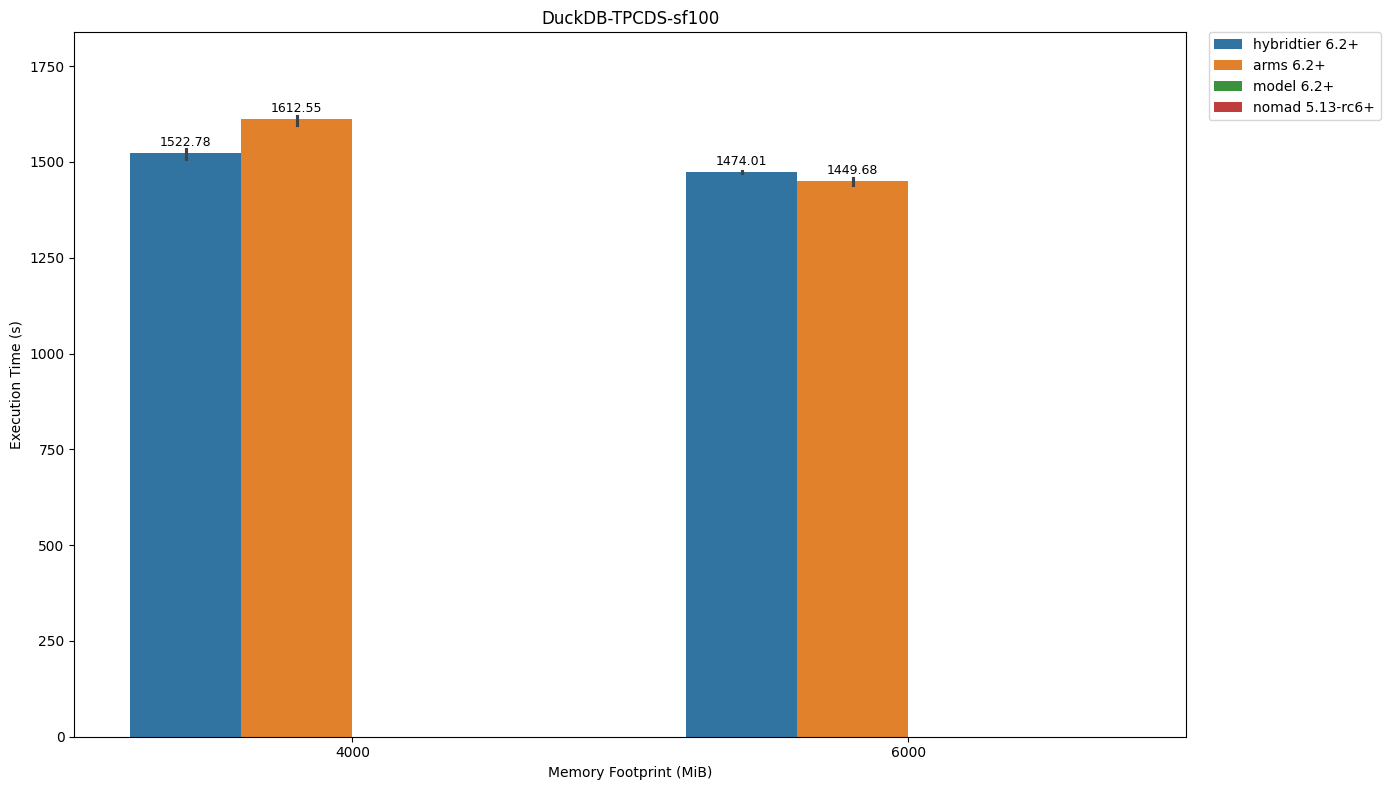

DuckDB-TPCH-sf100


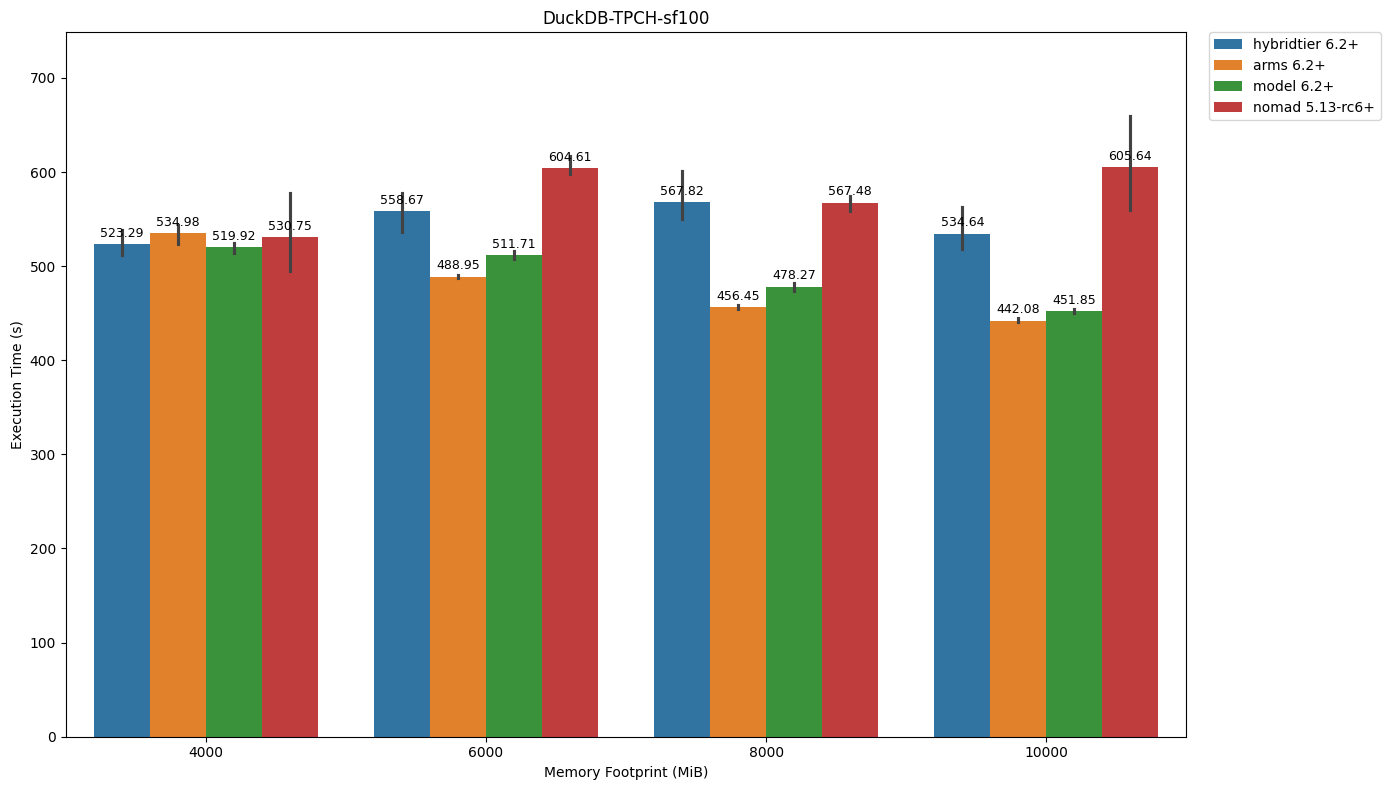

XSBench


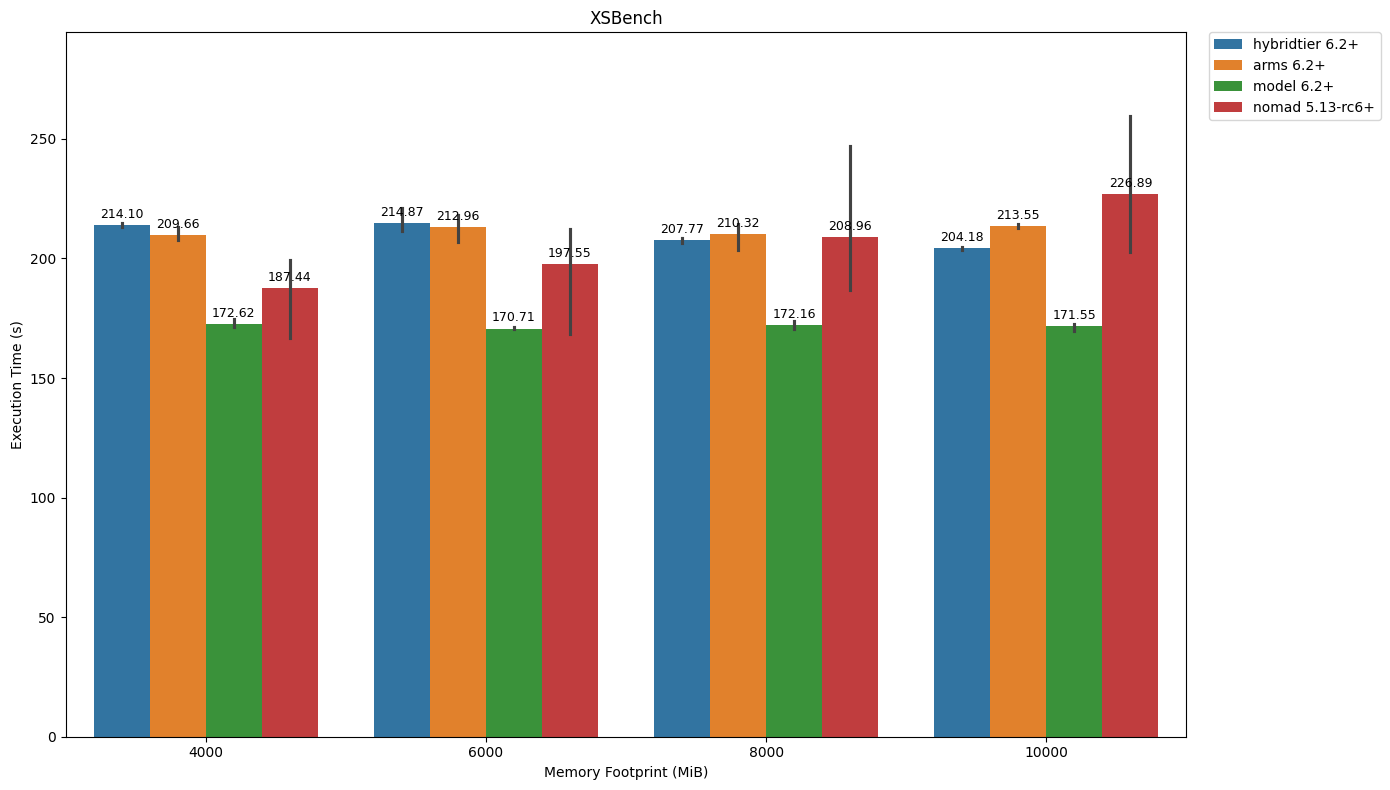

bc-kron.sg


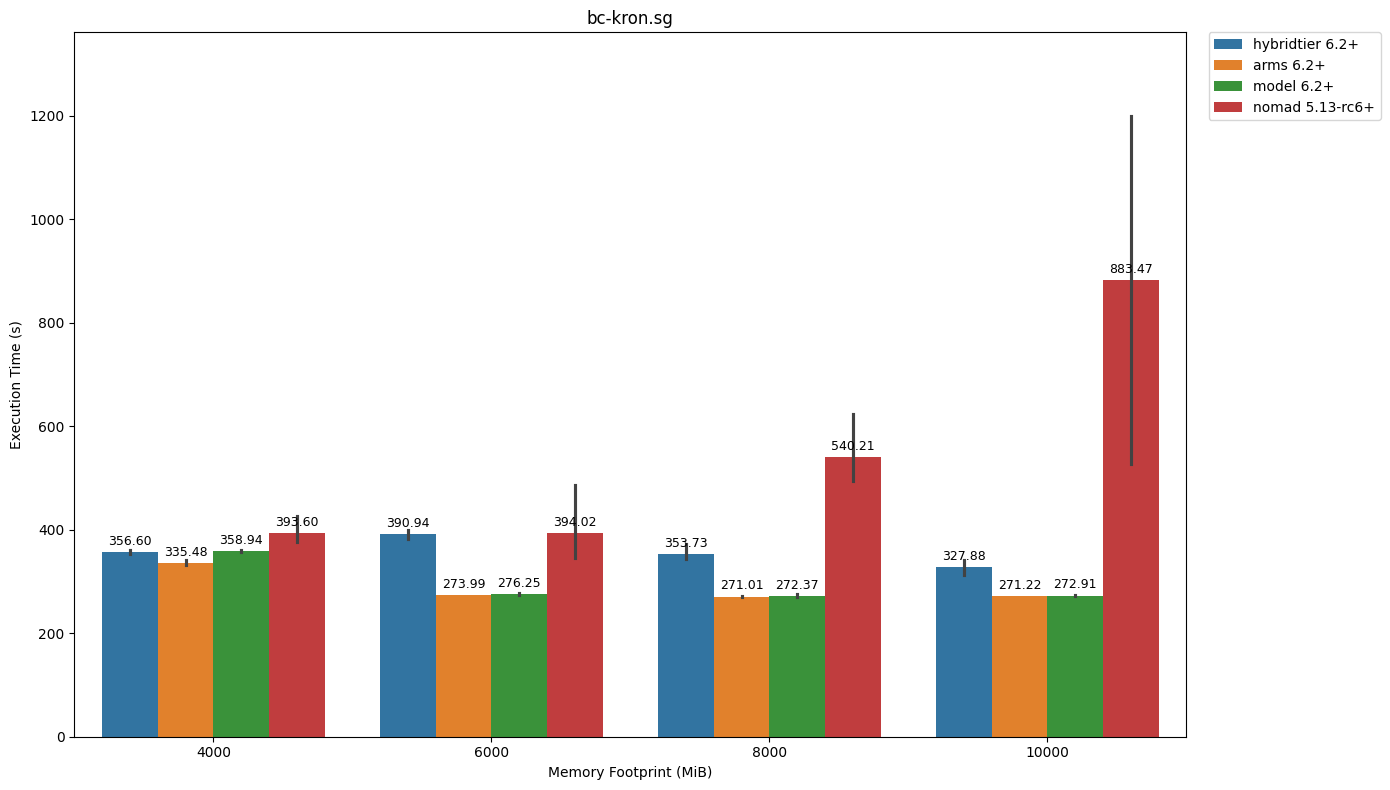

bc-twitter.sg


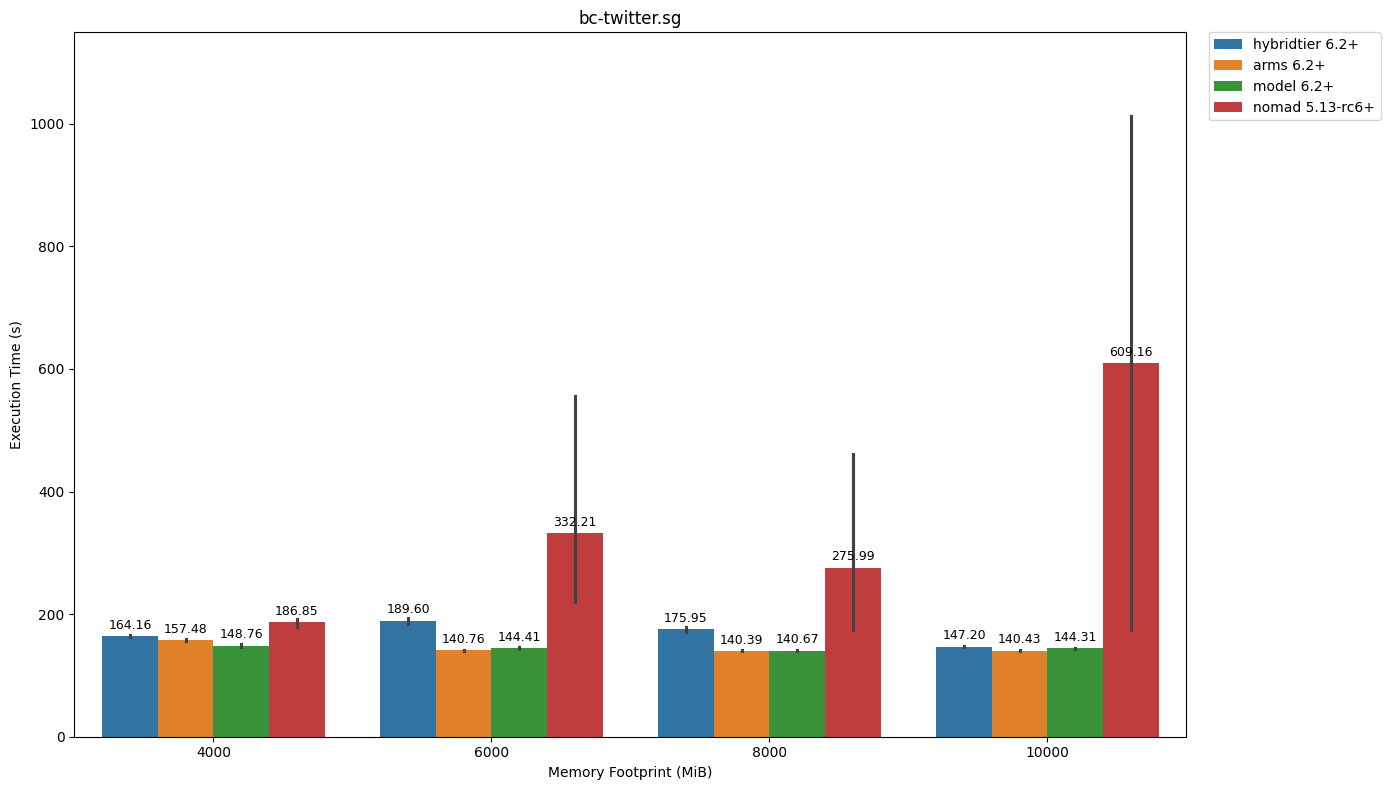

faiss_10M


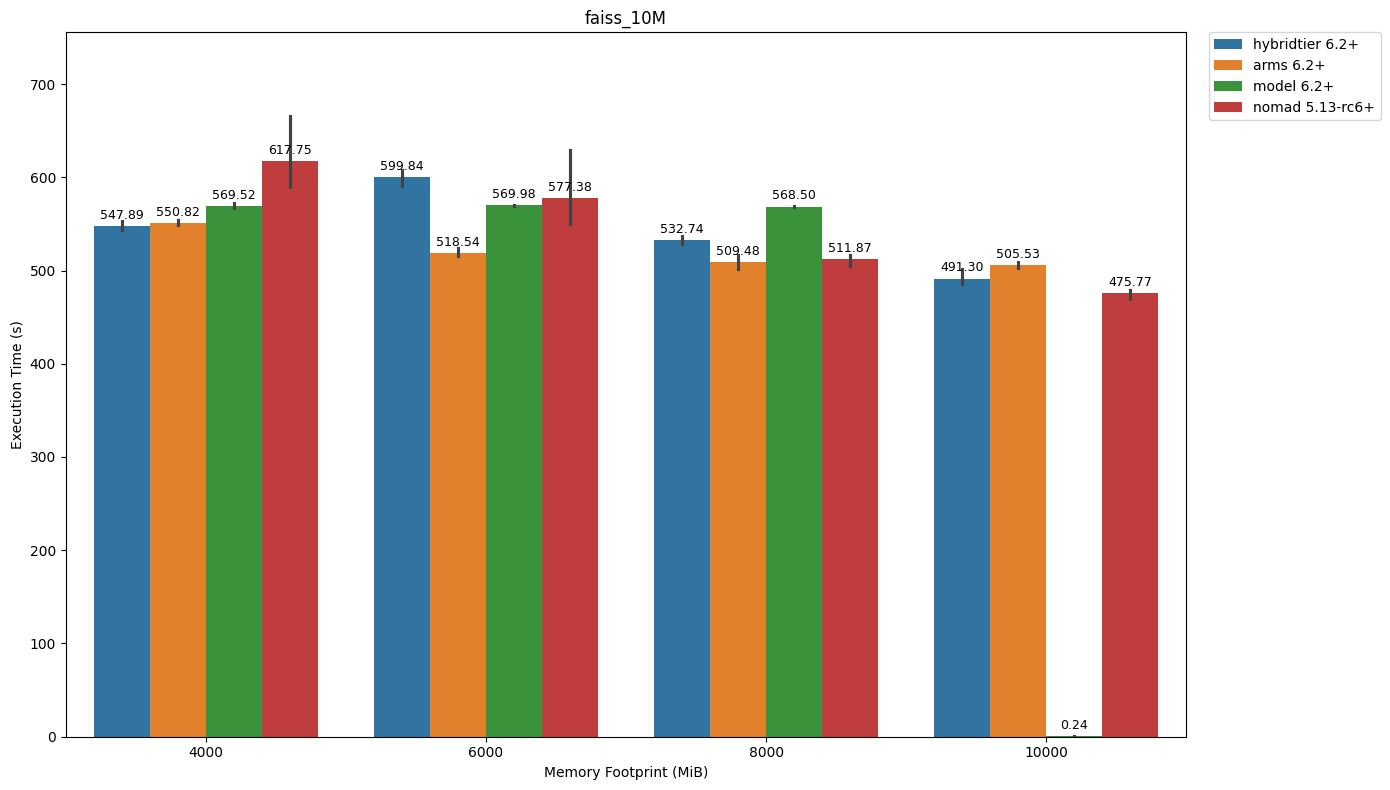

lulesh2.0_s400


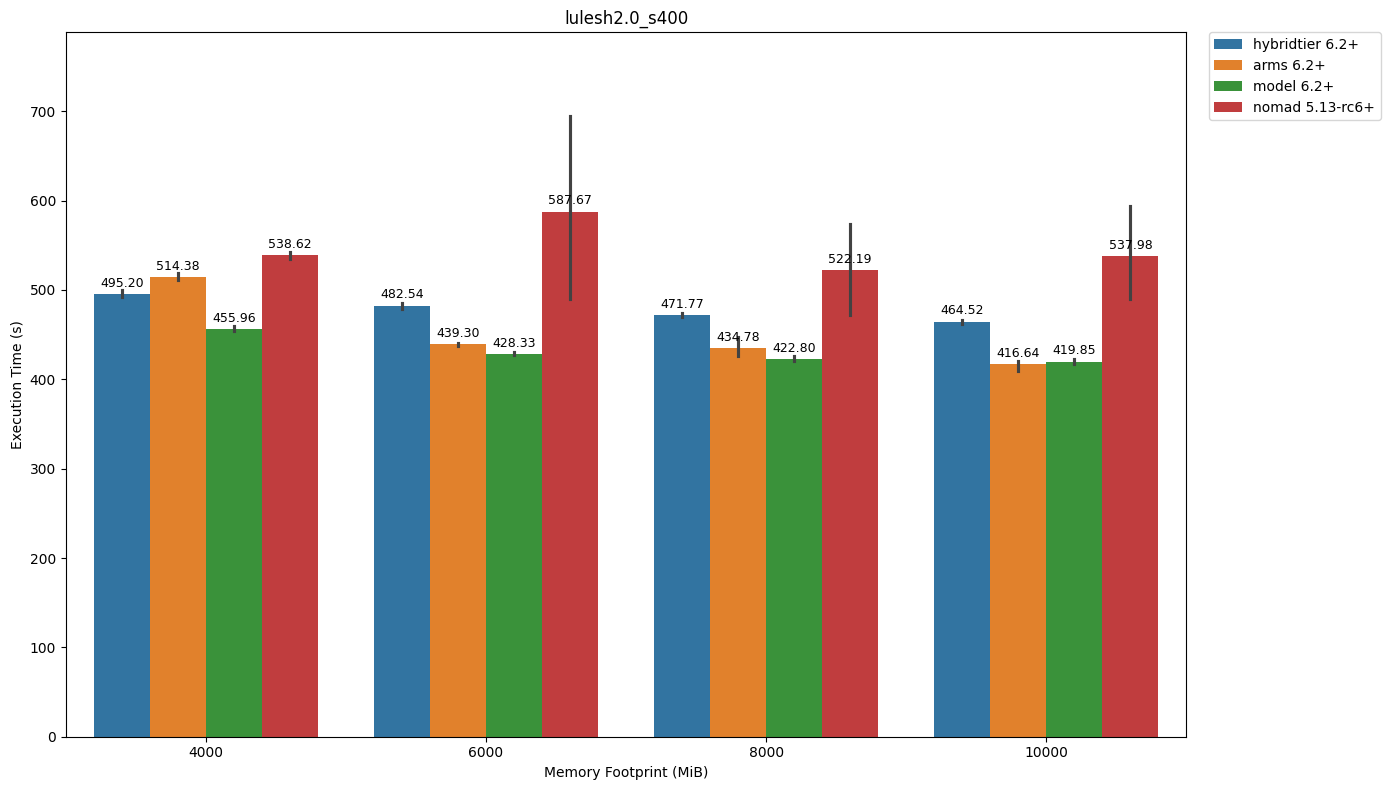

mg.D.x


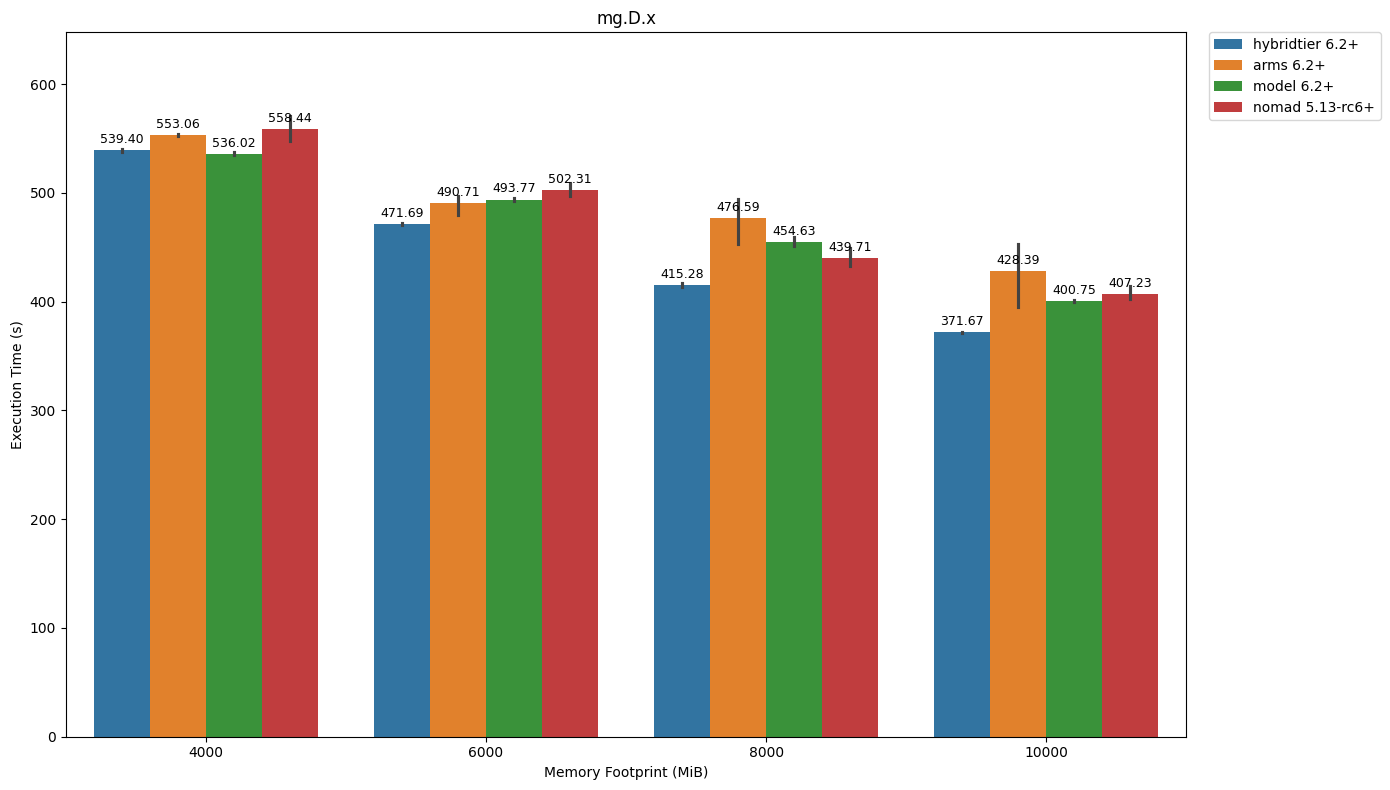

pr-kron.sg


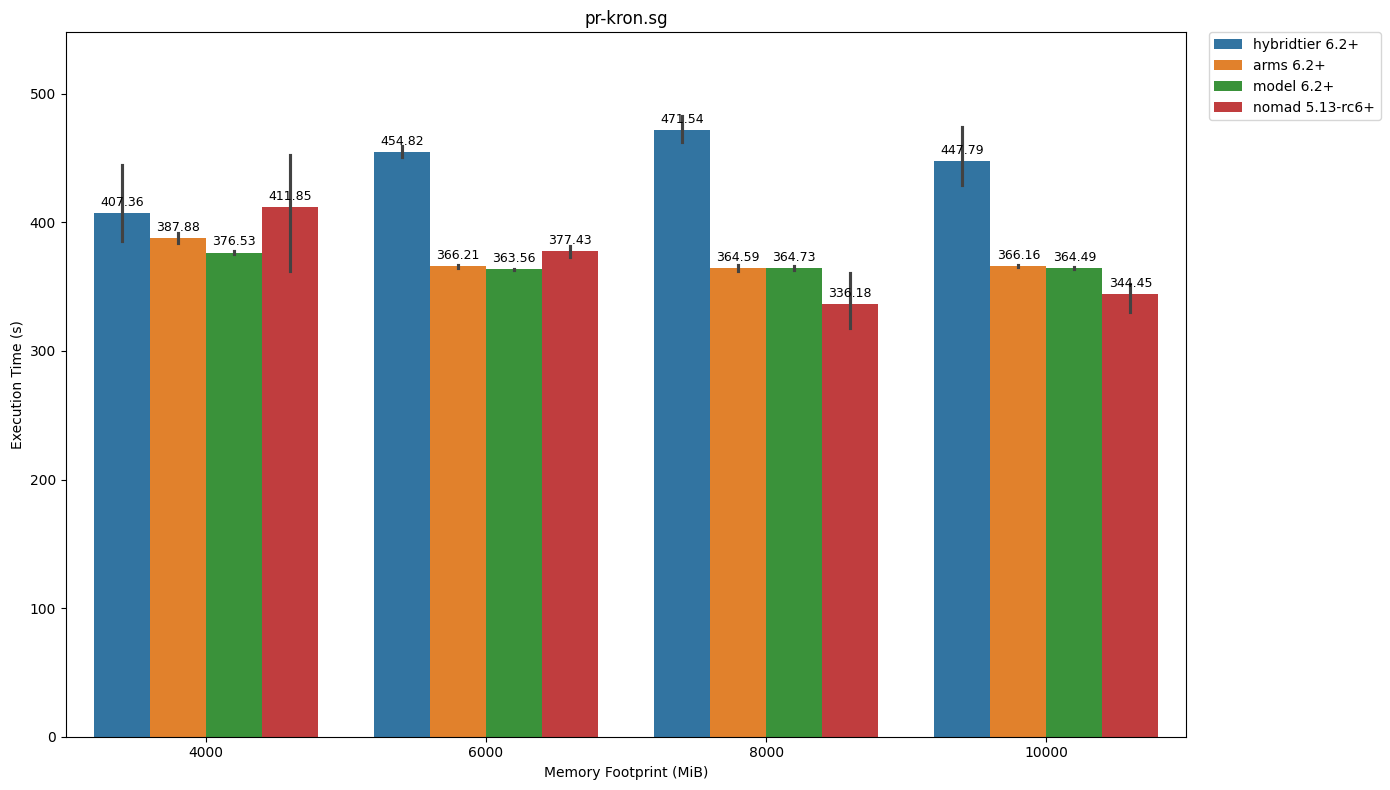

pr-twitter.sg


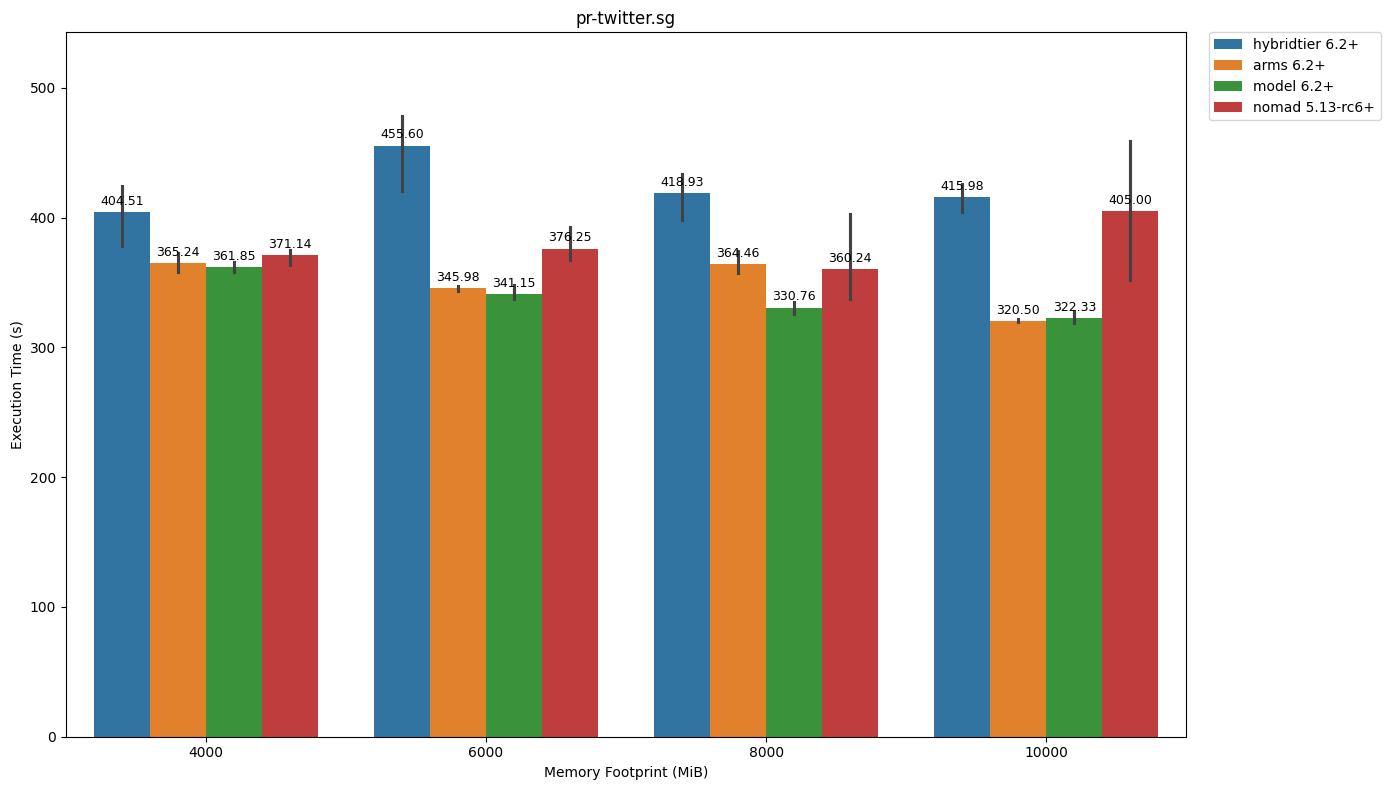

In [9]:
roots_6_2 = lambda workload: {
        #"arms 6.18": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/arms-6.18/{workload}")),
        "hybridtier 6.2+": ("6.2+", (Path(f"/users/zimooo2/tiering_solutions/times/hybridtier/{workload}"))),
        "arms 6.2+": ("6.2+", Path(f"/users/zimooo2/tiering_solutions/times/arms-6.2/{workload}")),
        "model 6.2+": ("6.2+", Path(f"/users/zimooo2/tiering_solutions/times/model-6.2/{workload}")),
        "nomad 5.13-rc6+": ("5.13-rc6+", Path(f"/users/zimooo2/tiering_solutions/times/nomad/{workload}")),
    }

df = generate_df(roots_6_2)
plot_df(df[df["MiB"] > 3000])

DuckDB-TPCH-sf100


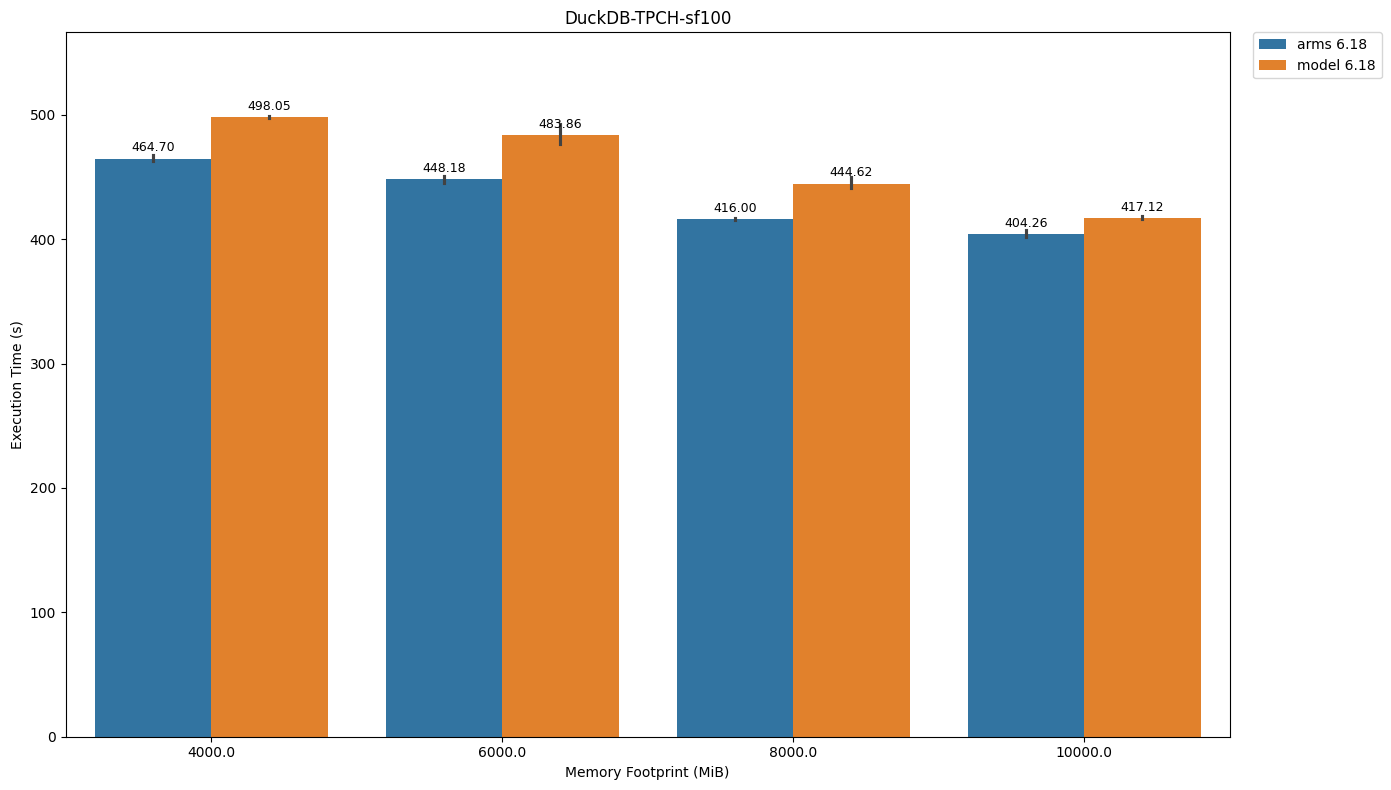

XSBench


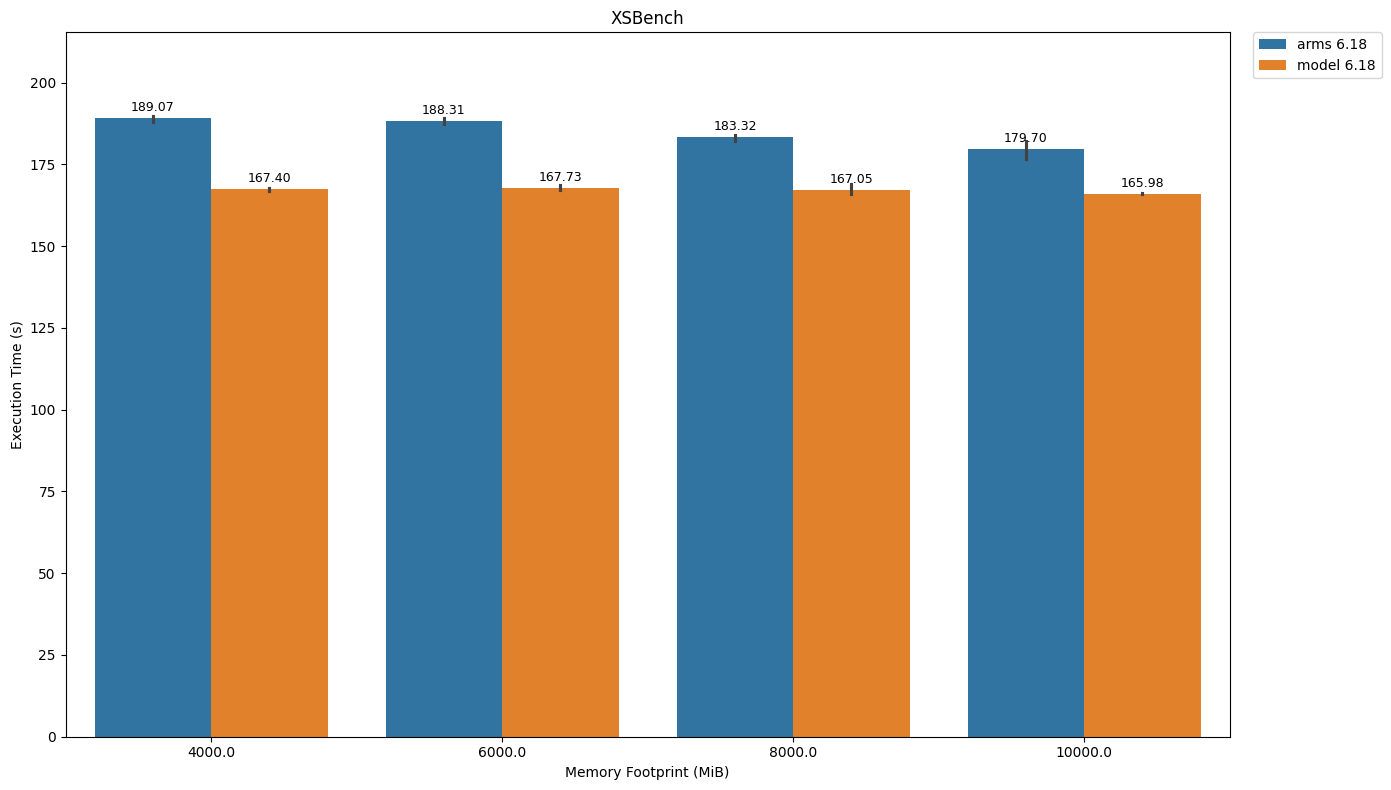

bc-kron.sg


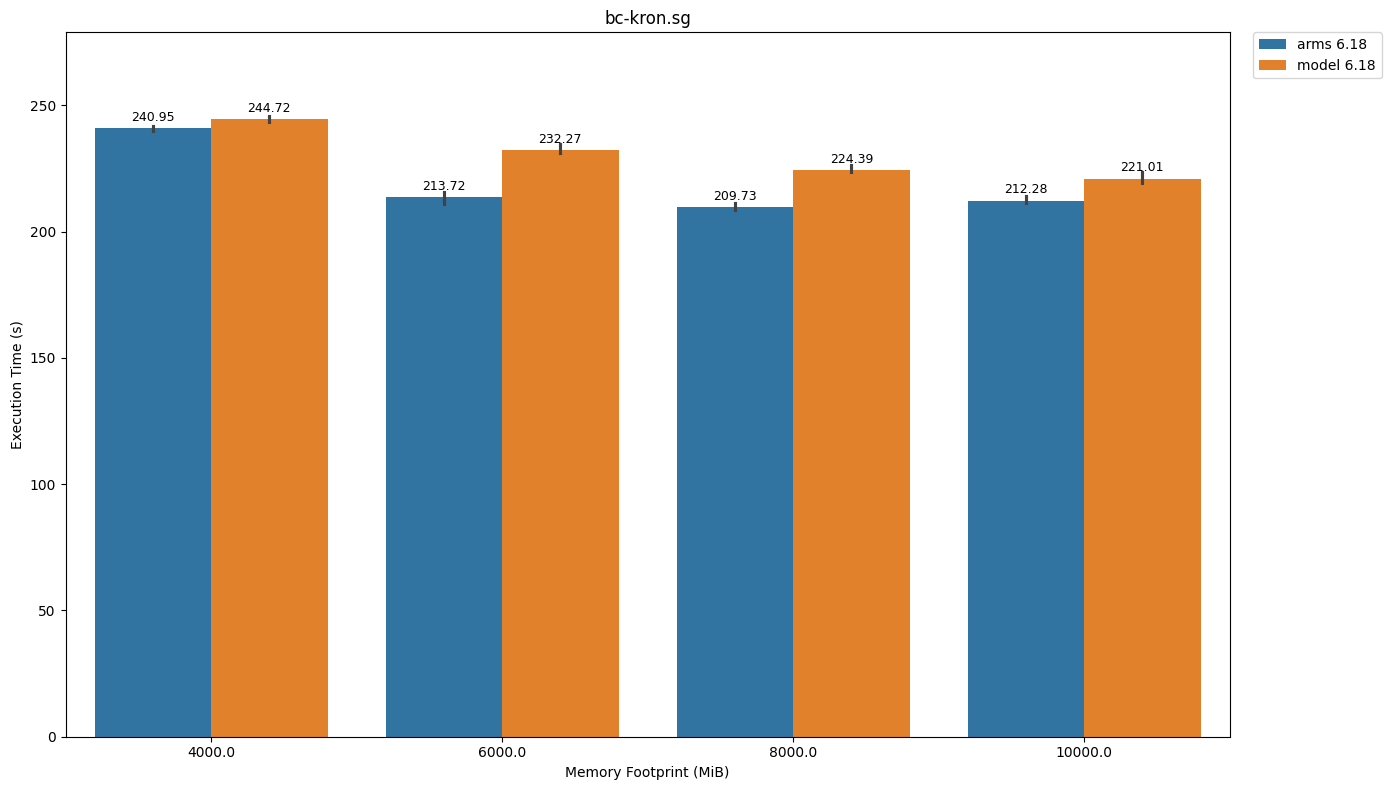

bc-twitter.sg


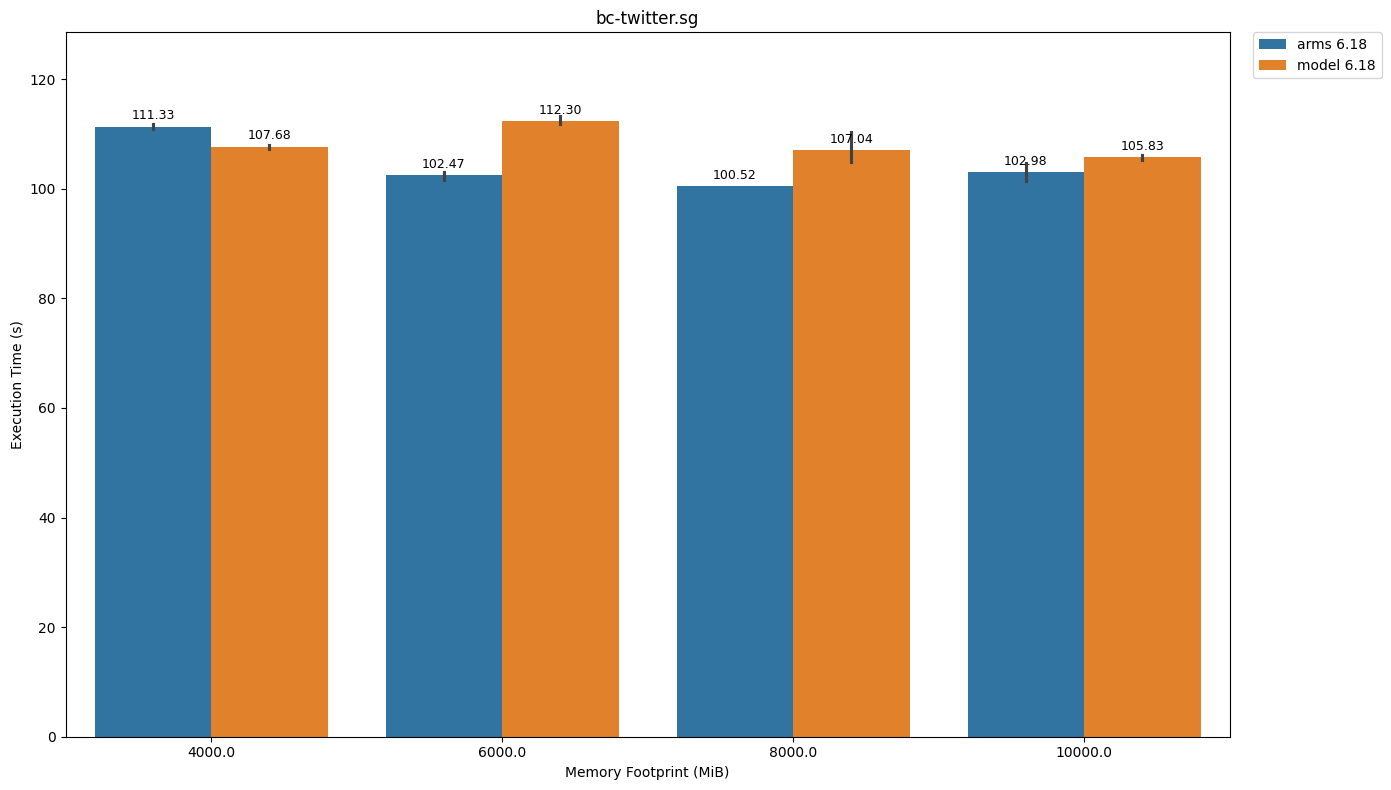

faiss_10M


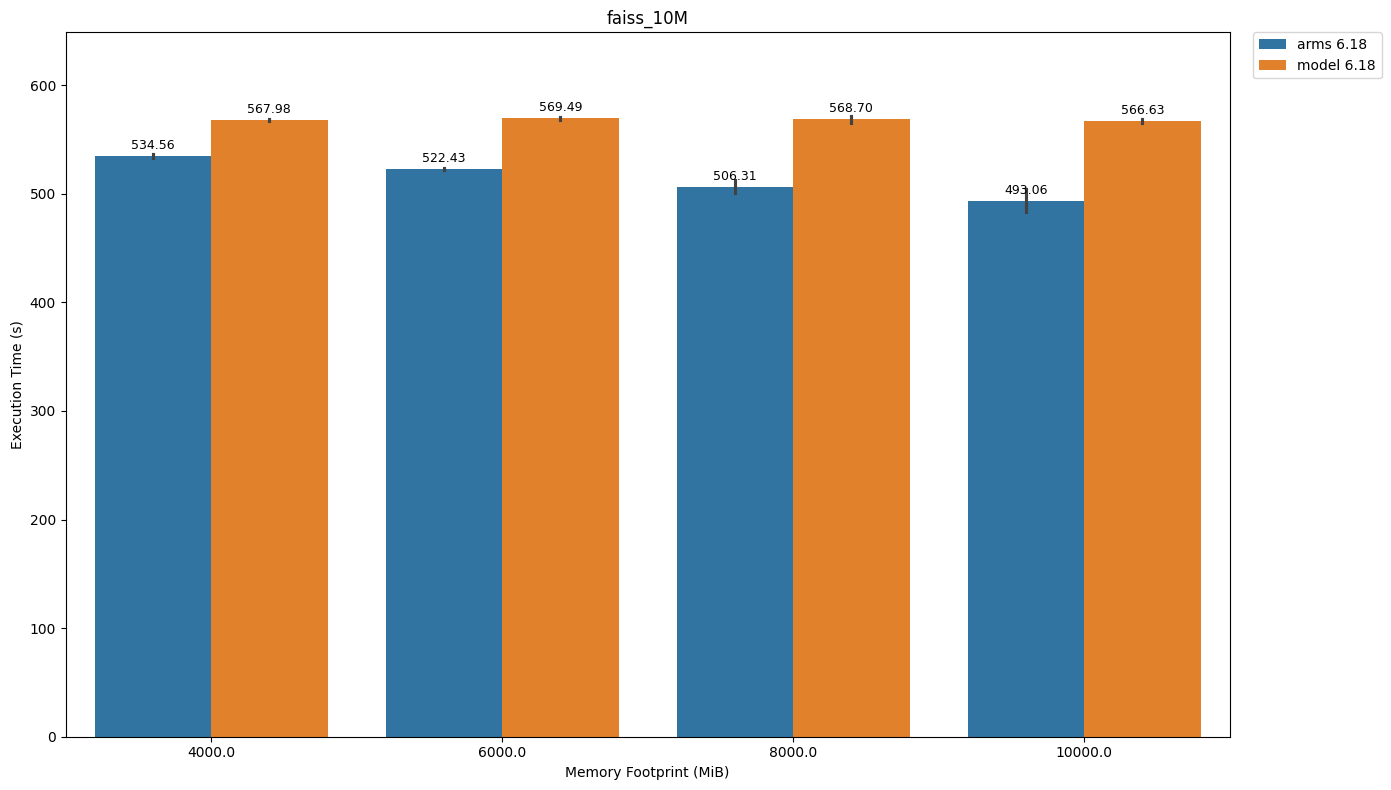

lulesh2.0_s400


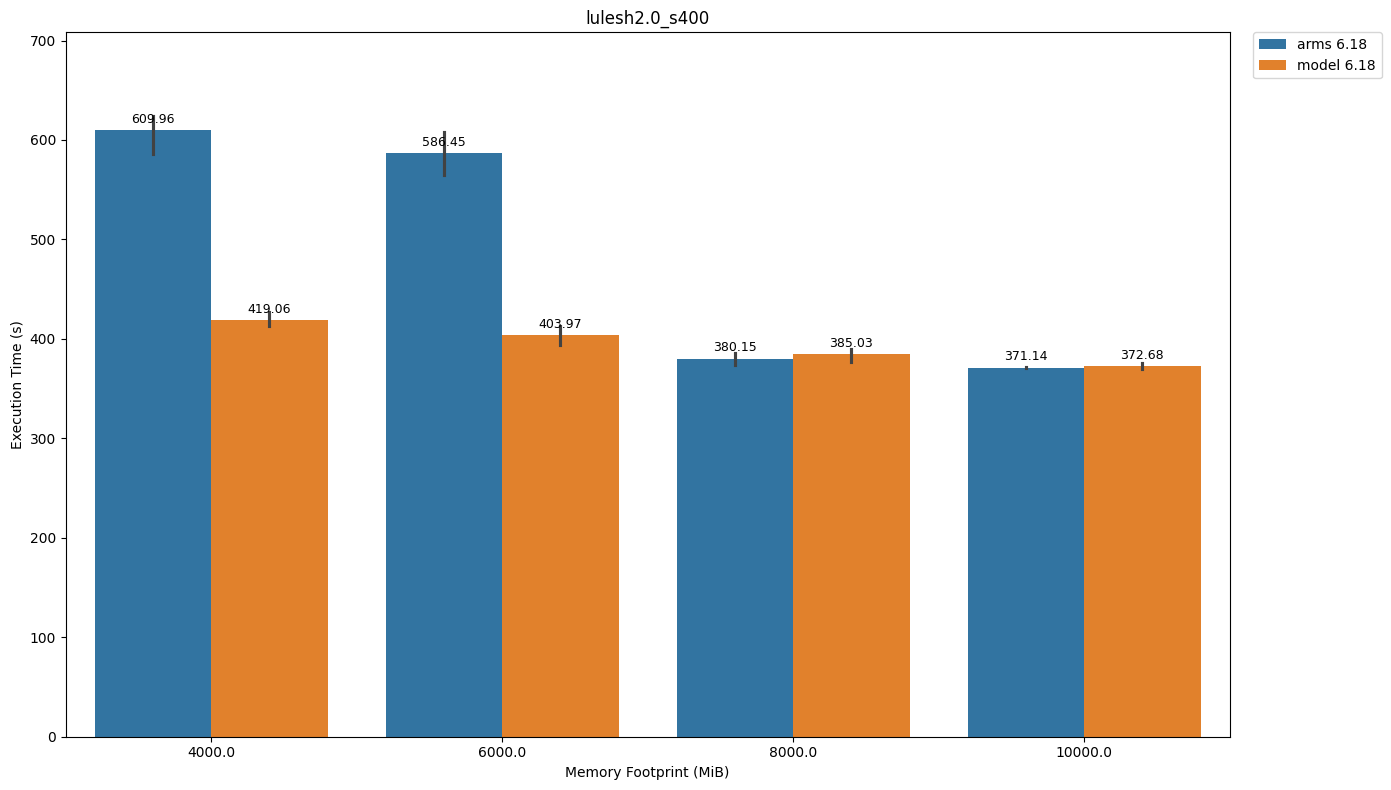

mg.D.x


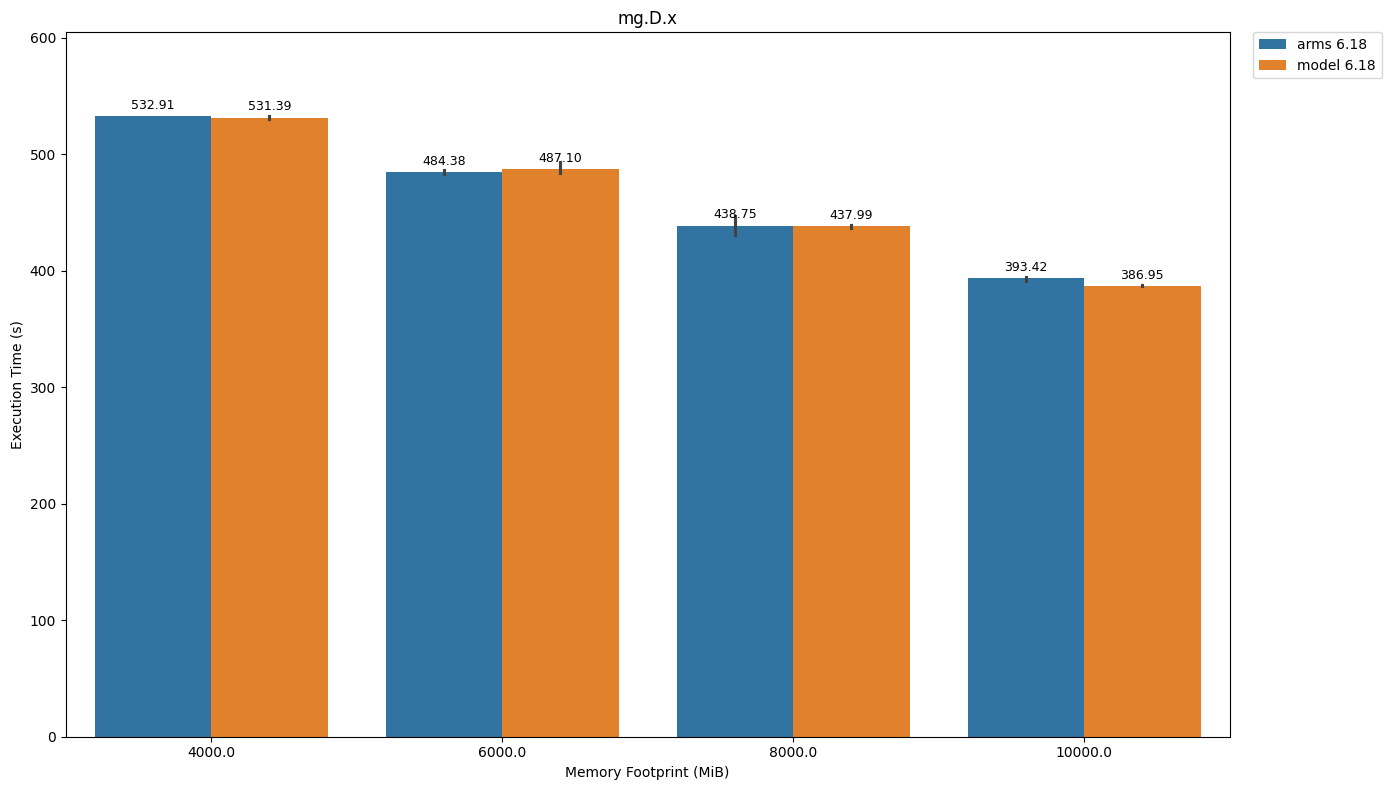

pr-kron.sg


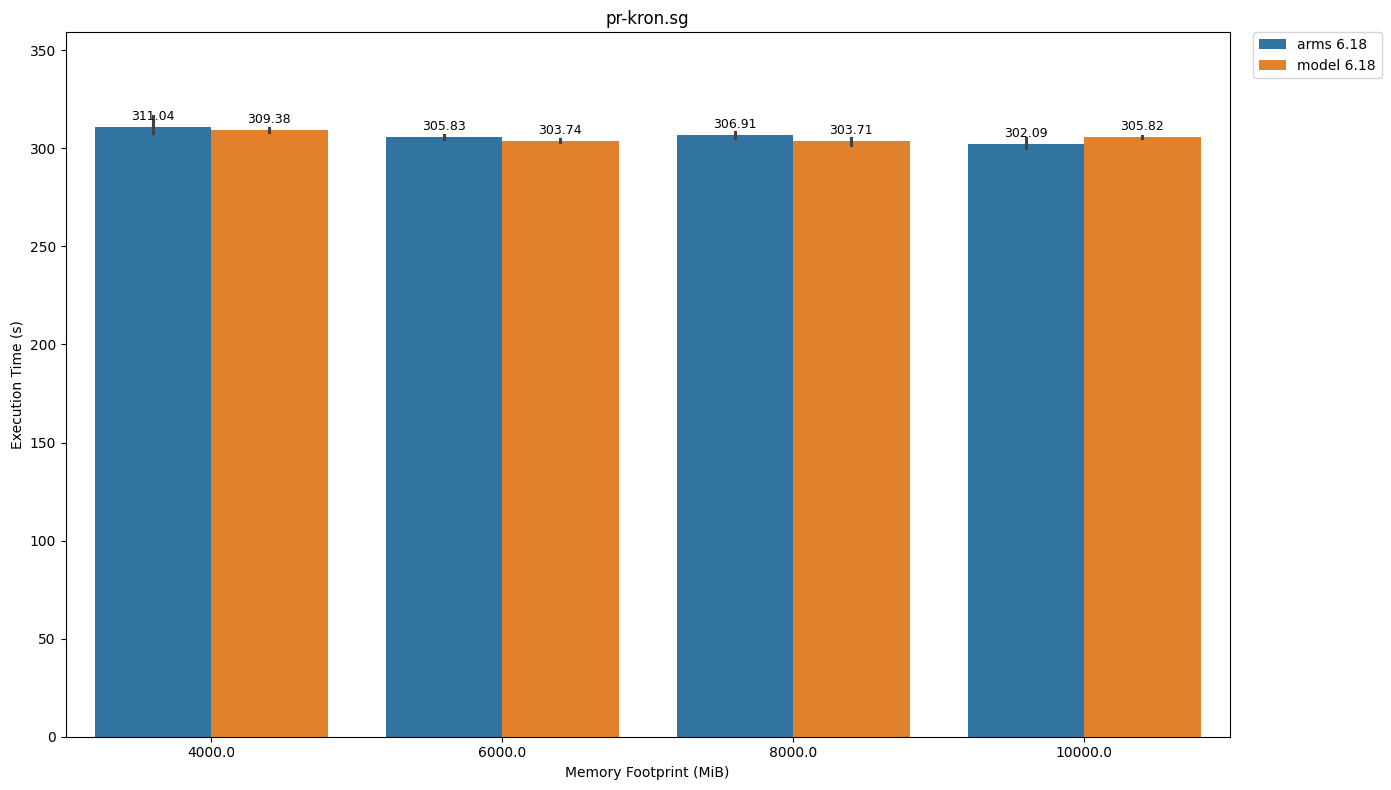

pr-twitter.sg


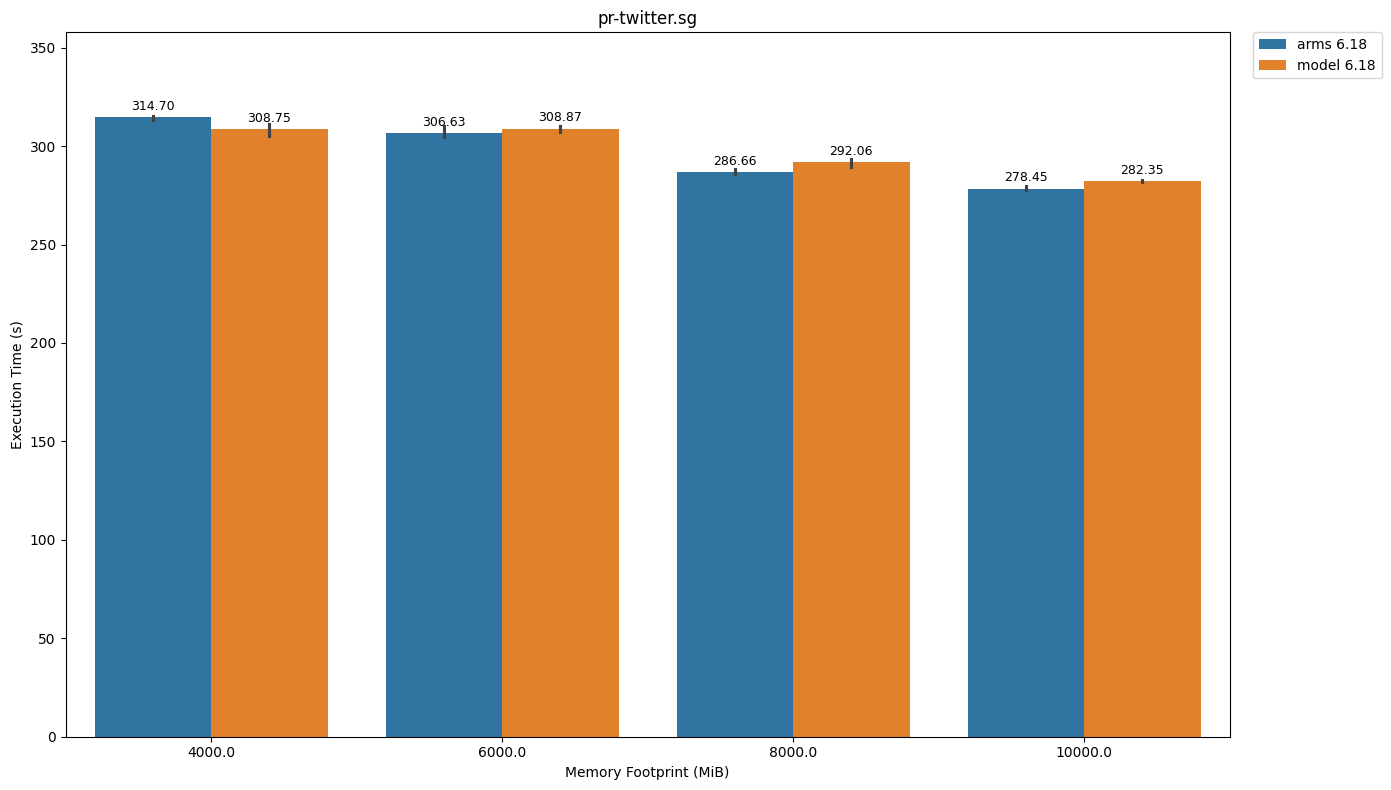

In [10]:
roots_6_18 = lambda workload: {
        "arms 6.18": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/arms-6.18/{workload}")),
        "model 6.18": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/model-6.18/{workload}")),
    }

df = generate_df(roots_6_18)
plot_df(df[df["MiB"] > 3000])